In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/betabluindev/cleaned-combined-dataset/cleaned_emotion_dataset.csv


# **Installing Dependencies**
---

In [1]:
!pip install -q transformers datasets evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


# **Loading Dataset**
---

In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/betabluindev/cleaned-combined-dataset/cleaned_emotion_dataset.csv")

df = df.rename(columns={
    'clean_text': 'text',
    'final_label': 'label'
})

print(df.head())

                                                text  label
0  lt steve between his feet feeling a blush stin...  anger
1  i remember reading it and feeling so envious o...  anger
2  im feeling a little too violent and my mother ...  anger
3  i still get surprised when i wake up feeling h...  anger
4  i didn t feel like i was impatient there last ...  anger


# **Label Encoding**
---

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

num_labels = len(le.classes_)
print(le.classes_)

['anger' 'disgust' 'fear' 'joy' 'neutral' 'sadness' 'surprise']


# **Train-Test Split**
---

In [4]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.1,
    stratify=df['label'],
    random_state=42
)

# **Convert to HuggingFace Dataset**
---

In [5]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "label": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    "text": val_texts.tolist(),
    "label": val_labels.tolist()
})

# **Tokenization Function**
---

In [6]:
from transformers import AutoTokenizer

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# **Metrics**
---

In [7]:
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="weighted")["f1"]
    }

# **Training Models**
---

## **RoBERTa**

### **Training Function**

In [8]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

def train_model(model_name):
    
    global tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_val = val_dataset.map(tokenize_function, batched=True)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    
    from transformers import DataCollatorWithPadding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=50,
        report_to ="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )
    
    trainer.train()
    
    results = trainer.evaluate()
    
    return trainer, results, tokenized_val   

In [9]:
roberta_trainer, roberta_results, tokenized_val = train_model("roberta-base")
print(roberta_results)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': 1.7366101741790771, 'eval_accuracy': 0.7205254515599343, 'eval_f1': 0.7216334324743054, 'eval_runtime': 30.32, 'eval_samples_per_second': 200.858, 'eval_steps_per_second': 6.299, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.67      0.71       901
           1       0.63      0.63      0.63       678
           2       0.84      0.73      0.78       863
           3       0.75      0.74      0.75       952
           4       0.60      0.69      0.64       815
           5       0.72      0.75      0.73       959
           6       0.75      0.80      0.77       922

    accuracy                           0.72      6090
   macro avg       0.72      0.72      0.72      6090
weighted avg       0.73      0.72      0.72      6090



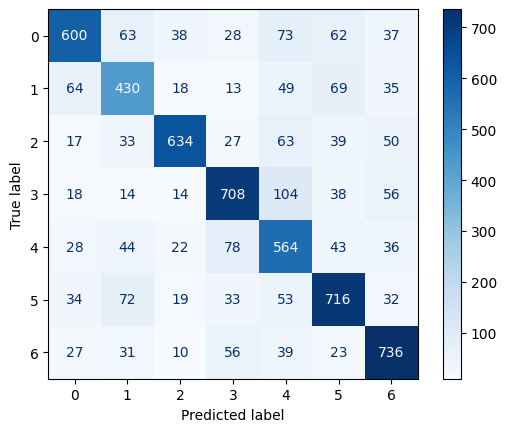

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Predictions
preds = roberta_trainer.predict(tokenized_val)
y_pred = preds.predictions.argmax(axis=1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(val_labels, y_pred))

# Confusion Matrix
cm = confusion_matrix(val_labels, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()



## **ELECTRA**

In [15]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

def train_model(model_name):
    
    global tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_val = val_dataset.map(tokenize_function, batched=True)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    
    from transformers import DataCollatorWithPadding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=50,
        report_to ="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )
    
    trainer.train()
    
    results = trainer.evaluate()
    
    return trainer, results, tokenized_val   

In [16]:
electra_trainer, electra_results = train_model("google/electra-base-discriminator")
print(electra_results)

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/54807 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

ValueError: too many values to unpack (expected 2)

## **ALBERT**